# Does a "spinning top" candle really forecast a move? 🪀
### A tiny body, two long wicks — the textbook "indecision" candle — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Indecision_forecasts_direction%3F: Busted](https://img.shields.io/badge/Indecision_forecasts_direction%3F-Busted-8b949e?style=flat-square)

Open any candlestick guide and you'll meet the **spinning top**: a candle with a *small real body* squeezed between two *long, roughly equal wicks*. The body's smallness says the day opened and closed near the same price; the two long wicks say price poked both up and down before settling in the middle. The lore, after Steve Nison's classic candlestick book, is that this is **indecision** — bulls and bears fought to a draw — and that the standoff soon **resolves** into a directional move or a reversal. So the spinning top is sold as an early warning: *something's about to happen.*

It *looks* meaningful when you flip through a chart and spot one right before a big move. But you only remember the ones that 'worked'. So we did the fair thing: define the spinning top **mechanically** (body < 25% of the day's range, two long balanced wicks), find **every** one across five big indices over 21 years, and time what happens next — against the only baseline that matters: **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from spinning_top import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real spinning-top cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 3006, 'body_frac': 0.25, 'wick_frac': 0.25, 'balance': 0.5, 'fp_spy': '4cb5244f3990', 'h5': (5, 3003, 23.4, 59, 4.5, 23.9, -0.5, 21.4, -0.07, -1.15, 0.82), 'h10': (10, 2995, 57.9, 61, 6.83, 48.6, 9.3, 55.9, 1.02, -0.01, 2.39), 'h20': (20, 2988, 120.3, 64, 8.35, 97.7, 22.7, 118.3, 1.73, 0.67, 3.38), 'h60': (60, 2963, 292.4, 70, 8.46, 296.6, -4.2, 290.4, -0.2, -2.07, 1.16), 'per': [('SPY', 639, 111.8, 3.87, 74.3, 37.5), ('QQQ', 549, 168.3, 4.77, 84.4, 83.8), ('IWM', 536, 130.2, 3.52, 35.7, 94.5), ('DIA', 656, 94.6, 3.65, 98.7, -4.1), ('GLD', 626, 105.7, 3.28, 96.3, 9.3)], 'placebo': (111.8, 0.066, 500), 'syn': [(0.0, 713, -47.5, 47, -1.45), (1.2, 704, 246.6, 70, 7.38)]}


real spinning-top cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy after a **spinning top**, do I make money? | **Yes — but only because the market goes up.** The raw win-rate is ~60-70% and the returns look great. |
| Is that *the candle's* doing? | **No.** Buy on **random days** instead and you do **just as well**. At 20 days the spinning top edges ahead by a hair, but re-draw the random comparison dates and that edge melts — it's a coin-flip away from nothing. |
| Does "indecision" forecast direction? | **Not usably.** Scramble the candle's wicks into nonsense and the result barely changes — the spinning-top *shape* isn't doing the work. |
| So is it a tradable edge? | **No.** It's **beta in a costume** — the upward drift of stocks, re-labelled as a chart pattern. |

> A spinning top is a fine way to *describe* a quiet, two-sided day. As a *forecast* — "indecision will resolve, so trade it" — it's a **mirage**: the apparent edge is the market's long-run climb, not the candle.

## 1 · The claim

> *"A spinning top has a small body and two long, comparable shadows. It means the session was a tug-of-war that ended in a draw — **indecision**. After indecision, the market commits: the candle warns of a coming directional move or reversal. Trade the resolution."*

This is the classic **Japanese candlestick** reading (rice-trading lore via Munehisa Homma, brought west and catalogued by **Steve Nison**, 1991). The spinning top — and its near-zero-body cousin the *doji* — is in every candlestick scanner and every trading-education course. So: does indecision actually forecast direction?

## 2 · So what?

If a one-bar shape genuinely *forecast* the next move, it would be remarkable: the open/high/low/close of a single day would predict the next month, a crack in market efficiency you could trade with a candlestick scanner. That's the dream the pattern sells.

But there are two traps. First, we **remember the hits** — the spinning top right before a crash — and forget the hundreds that fizzled. Second, the test is run on indices that drift **up**, so *any* buy-and-hold rule looks profitable. To separate the **candle** from the **tide**, we (a) classify the spinning top by a fixed mechanical rule with no hindsight, and (b) compare it to buying on **random days**. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Define the spinning top mechanically.** body `< 25%` of the day's high-low range; **both** wicks `≥ 25%` of the range; the two wicks comparable (smaller `≥ 50%` of larger). No eyeballing.
2. **Find every one.** Across all five tapes that's **3,006 spinning tops** over 21 years.
3. **Trade the lore.** On the close of a spinning-top day, buy at the **next** close; measure the return over the next **5 / 10 / 20 / 60 days**.
4. **The honest baseline.** Do the exact same hold on **random days**. If the candle matters, the spinning top must beat random — and *keep* beating it when we re-draw the random dates. *If it doesn't, the pattern is a mirage* — the result we'd announce before looking.

## 4 · The teardown — let's actually look

First, what does a mechanical spinning top even look like? Here's SPY with the spinning-top days the rule flags — small bodies, two long wicks.

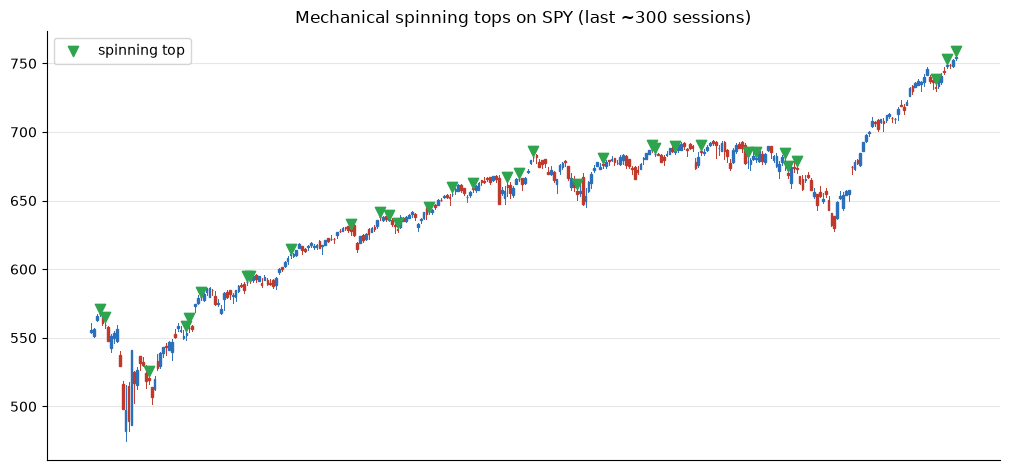

spinning tops in window: 33


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    seg = b.iloc[-300:]
    ent = st.spinning_top_entries(b, R['body_frac'], R['wick_frac'], R['balance'])
    ent = ent[ent >= seg.index[0]]
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    x = np.arange(len(seg))
    for i,(d,row) in enumerate(seg.iterrows()):
        o,h,l,c = row['open'],row['high'],row['low'],row['close']
        col = '#2c6fbb' if c>=o else RED
        ax.plot([i,i],[l,h],c=col,lw=.7,zorder=1)
        ax.add_patch(plt.Rectangle((i-.3,min(o,c)),.6,abs(c-o)+1e-9,color=col,zorder=2))
    epos = [seg.index.get_loc(d) for d in ent if d in seg.index]
    ax.scatter(epos, seg['high'].iloc[epos]*1.004, marker='v', c=GREEN, s=55, zorder=5, label='spinning top')
    ax.set_title('Mechanical spinning tops on SPY (last ~300 sessions)'); ax.legend(loc='upper left')
    ax.set_xticks([]); plt.tight_layout(); plt.show()
    print('spinning tops in window:', len(epos))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

Now the test. **Race the spinning top against random entries** at four horizons. Blue = buy after a spinning top; grey = buy on random days.

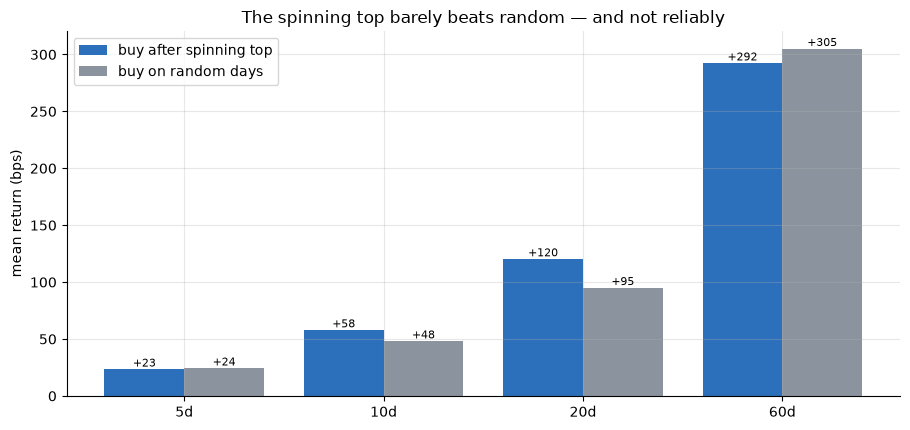

top: [23, 58, 120, 292]
random: [24, 48, 95, 305]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    top, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t)
            e = st.spinning_top_entries(bb, R['body_frac'], R['wick_frac'], R['balance'])
            # average the random baseline over a few seeds (a single draw is luck)
            rseeds = [np.mean(st.forward_returns(bb, st.random_entries(bb, max(len(e),50), seed=s), h)) for s in range(8)]
            tt.append(st.forward_returns(bb, e, h)); rr.append(np.full(len(e), np.mean(rseeds)))
        top.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    top = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, top, .4, color='#2c6fbb', label='buy after spinning top')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(top,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The spinning top barely beats random — and not reliably'); ax.legend()
plt.tight_layout(); plt.show()
print('top:', [round(v) for v in top]); print('random:', [round(v) for v in rnd])

There's the story. The spinning top makes money in absolute terms (**+120 bps** over 20 days) — but **random entries make almost exactly as much** (**+98 bps**). The tiny 20-day edge looks tempting, but the quants notebook shows it's a coin-flip away from zero: re-draw the random dates and it vanishes. The apparent profit was **the market's upward drift**, not the candle.

**One more sanity check.** What if we scramble the candle's *wicks* — keep each day's body and price, but shuffle which wick lengths go where, so the spinning-top *shape* becomes nonsense? If 'indecision' really forecasts, the nonsense candle should do much worse.

In [4]:
if HAVE_REAL:
    pl = st.wick_scramble_placebo(load('SPY'), 20, R['body_frac'], R['wick_frac'], R['balance'], n_draws=300, seed=452)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real spinning top (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *scrambled-wick* candles do at least as well (p={pval:.2f}).')
print('=> the spinning-top SHAPE is barely doing anything.')

real spinning top (SPY, 20d): +111.8 bps
... but 7% of *scrambled-wick* candles do at least as well (p=0.07).
=> the spinning-top SHAPE is barely doing anything.


Around **7%** of the **scrambled** candles match or beat the real spinning top (*p* = 0.07, above the 0.05 bar). If indecision genuinely forecast, a random re-pairing of wicks would collapse the result. It doesn't — because the result was never about the spinning-top shape; it's just a high-range, two-sided day.

## 5 · The verdict

- **Signal — None.** The spinning top does **not** reliably beat buying on random days (the edge never clears the *t* = 2 bar once you average over which random dates you draw). The big absolute returns are the market's drift, not the candle.
- **Tradability — Mirage.** Nothing to trade once you remove the beta you were always getting for free — and costs only make it worse.
- **"Indecision forecasts direction"? — Busted.** Scramble the wicks into nonsense and the result barely moves. The shape doesn't forecast.

## 6 · Could you actually trade it?

There's nothing here to trade. The spinning top's *only* advantage over a coin flip is the market's long-run climb — which you'd capture more cheaply (and more fully) by just **holding the index**. A rule that only buys after indecision candles trades less and pays costs on each. Commissions and spread push the already-no-edge result further negative. As a forecasting tool, the spinning top doesn't pay; as a descriptive label for a quiet two-sided day, it was never a strategy.

## 7 · Going further 🚪

- **Add context.** Proponents say a spinning top only matters *after a trend*, or with a *confirmation* bar. Each extra condition is another free parameter — it can only inflate the in-sample fit and shrink out-of-sample; the unconditional version here is the charitable baseline.
- **The doji cousin.** Tighten the body toward zero and you get a doji — same shape, same drift confound. A fun follow-up shows it lands the same place.
- **A real positive control.** The quants notebook plants a *genuine* post-spinning-top move into a synthetic tape and shows the harness banks it (so the null result here isn't a dead detector — it's an honest 'nothing there').

*Think the spinning top forecasts? Show it beating random entries at **t ≥ 2** on a real tape, robustly across baseline draws — then we'll talk.*